In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
from matplotlib.cm import get_cmap
import matplotlib.gridspec as gridspec
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize



# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

In [2]:
# Load saved data
with open('../src/training_data.pkl', 'rb') as f:
    training_data = pickle.load(f)

with open('../results/output/threshold_data.pkl', 'rb') as f:
    threshold_data = pickle.load(f)

print(f"Training data contains {len(training_data)} alpha values")
print(f"Threshold data contains {len(threshold_data)} alpha values")

Training data contains 9 alpha values
Threshold data contains 9 alpha values


In [3]:
# Define alpha values
ALPHA_VALUES = [0.0, 0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

# Explore training data structure
alpha = ALPHA_VALUES[0]  # Look at alpha=0.0
print(f"Alpha {alpha} has {len(training_data[alpha])} seeds")

# Get a seed (directory timestamp)
seed = list(training_data[alpha].keys())[0]
print(f"Seed {seed} has data for {len(training_data[alpha][seed])} epochs")

# Look at metrics for one epoch
epoch = max(training_data[alpha][seed].keys())
print(f"Final epoch {epoch} metrics:", training_data[alpha][seed][epoch])

# Explore threshold data structure
thresholds = list(threshold_data[alpha].keys())
print(f"Alpha {alpha} has data for {len(thresholds)} thresholds")
print(f"Available thresholds: {sorted(thresholds)}")

# Look at scores for a threshold
threshold = thresholds[0]
print(f"For threshold {threshold}, g_score has {len(threshold_data[alpha][threshold]['g_score'])} values (one per seed)")
print(f"g_scores: {threshold_data[alpha][threshold]['g_score']}")

Alpha 0.0 has 5 seeds
Seed 20250513_030750 has data for 15 epochs
Final epoch 15 metrics: {'g_score': 0.518, 'i_score': 0.9, 'ood_g_score': 0.545, 'epoch': 15}
Alpha 0.0 has data for 16 thresholds
Available thresholds: [np.float64(0.0), np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(40.0), np.float64(50.0), np.float64(60.0), np.float64(70.0), np.float64(80.0), np.float64(90.0), np.float64(100.0), np.float64(110.0), np.float64(120.0), np.float64(130.0), np.float64(140.0), np.float64(150.0)]
For threshold 0.0, g_score has 5 values (one per seed)
g_scores: [np.float64(0.518), np.float64(0.468), np.float64(0.496), np.float64(0.491), np.float64(0.496)]


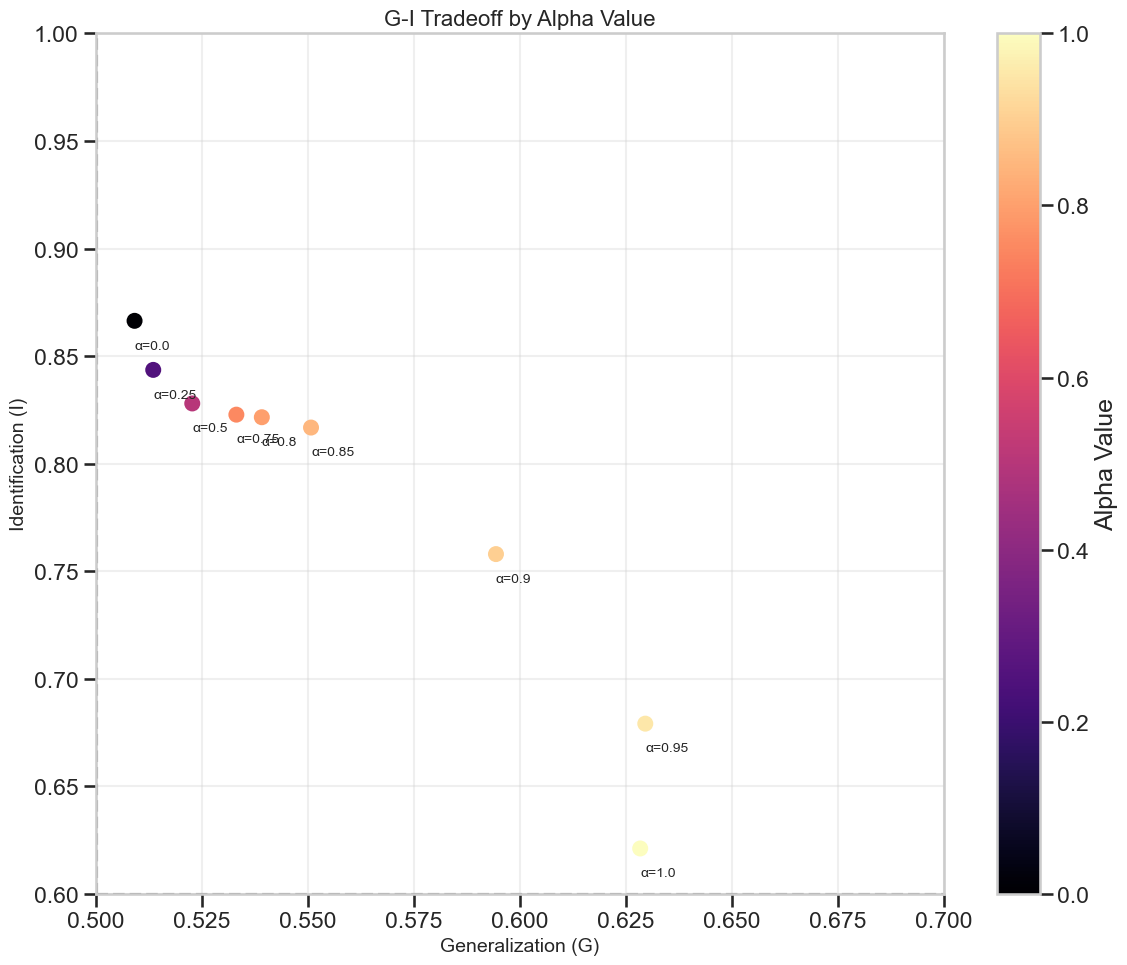

In [4]:
# Create color map for alpha values
colors = plt.cm.magma(np.linspace(0, 1, len(ALPHA_VALUES)))
alpha_color_map = {alpha: colors[i] for i, alpha in enumerate(ALPHA_VALUES)}

# Collect final G and I scores for each alpha (averaging across seeds)
final_g = []
final_i = []

for alpha in ALPHA_VALUES:
    g_scores_by_seed = []
    i_scores_by_seed = []
    
    for seed in training_data[alpha]:
        # Find the maximum epoch for this seed
        max_epoch = max(training_data[alpha][seed].keys())
        g_scores_by_seed.append(training_data[alpha][seed][max_epoch]['g_score'])
        i_scores_by_seed.append(training_data[alpha][seed][max_epoch]['i_score'])
    
    # Average across seeds
    if g_scores_by_seed and i_scores_by_seed:
        final_g.append(np.mean(g_scores_by_seed))
        final_i.append(np.mean(i_scores_by_seed))
    else:
        print(f"Warning: No data for alpha={alpha}")
        final_g.append(np.nan)
        final_i.append(np.nan)

# Filter out NaN values
valid_indices = ~np.isnan(final_g) & ~np.isnan(final_i)
valid_alphas = [ALPHA_VALUES[i] for i in range(len(ALPHA_VALUES)) if valid_indices[i]]
valid_g = [final_g[i] for i in range(len(final_g)) if valid_indices[i]]
valid_i = [final_i[i] for i in range(len(final_i)) if valid_indices[i]]
valid_colors = [alpha_color_map[alpha] for alpha in valid_alphas]

# Plot the G-I tradeoff curve
plt.figure(figsize=(12, 10))
scatter = plt.scatter(valid_g, valid_i, c=valid_alphas, cmap='magma', s=100)

# Add alpha labels
for i, alpha in enumerate(valid_alphas):
    plt.annotate(f"$\\alpha$={alpha}", (valid_g[i], valid_i[i]), 
                 xytext=(0, -20), textcoords='offset points', fontsize=10)
                
                

#remove split lines
plt.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=0.6, color='black', linestyle='--', alpha=0.5)

plt.xlim(0.5, 0.7)
plt.ylim(0.6, 1)
plt.colorbar(scatter, label='Alpha Value')
plt.xlabel('Generalization (G)', fontsize=14)
plt.ylabel('Identification (I)', fontsize=14)
plt.title('G-I Tradeoff by Alpha Value', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

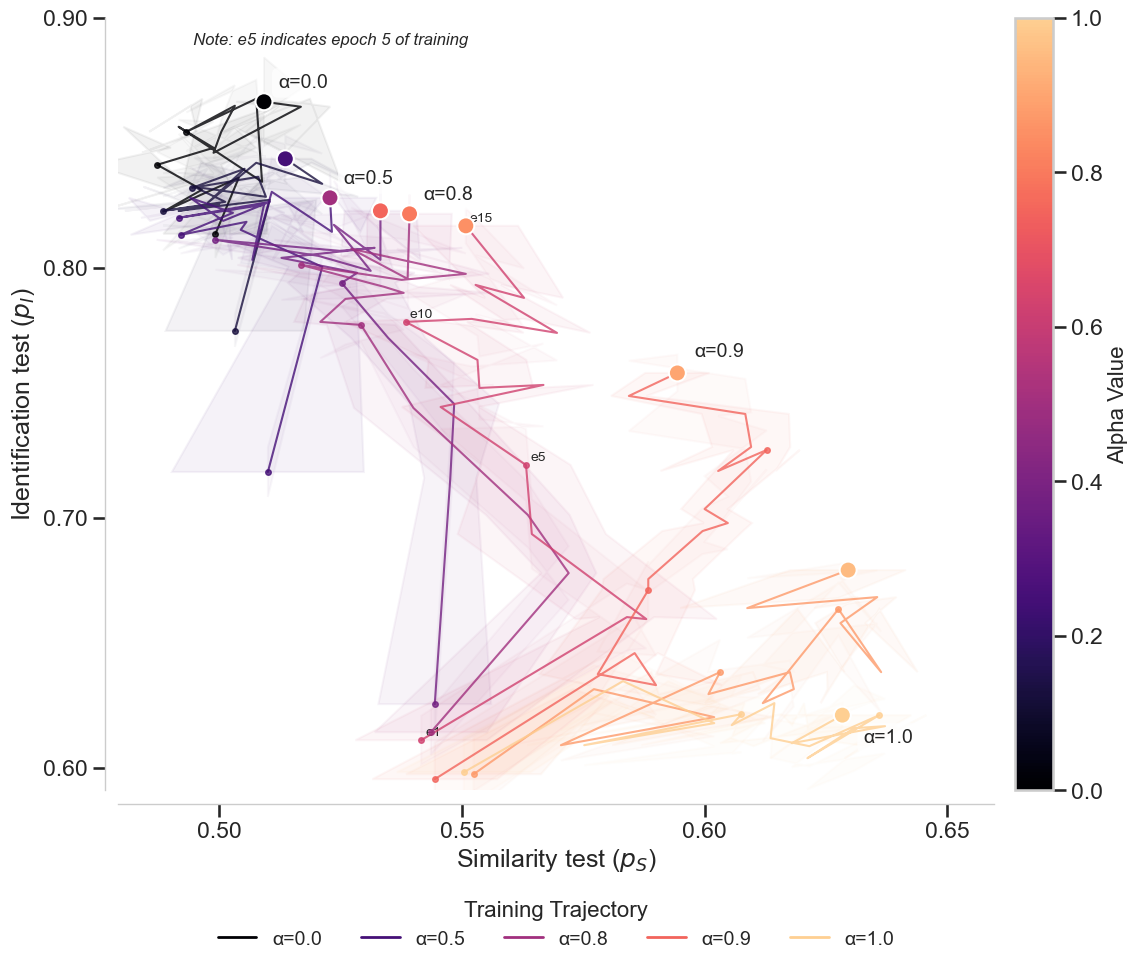

In [5]:
# Create color map for alpha values
cmap_magma = plt.cm.magma
colors = plt.cm.magma(np.linspace(0, 0.9, len(ALPHA_VALUES)))
alpha_color_map = {alpha: colors[i] for i, alpha in enumerate(ALPHA_VALUES)}

truncated_magma = ListedColormap(plt.cm.magma(np.linspace(0, 0.9, 256)))

# Set up an improved figure with larger fonts
plt.figure(figsize=(14, 10))  # Slightly wider to accommodate legend
plt.rcParams.update({
    'font.size': 18,  # Larger base font size
    'font.family': 'sans-serif',  # Cleaner font family
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica']  # Preferred fonts
})
plt.rcParams['axes.facecolor'] = 'white'
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.3, color='white')

# Collect final G and I scores for each alpha (averaging across seeds)
final_g = []
final_i = []

for alpha in ALPHA_VALUES:
    g_scores_by_seed = []
    i_scores_by_seed = []
    
    for seed in training_data[alpha]:
        # Find the maximum epoch for this seed
        max_epoch = max(training_data[alpha][seed].keys())
        g_scores_by_seed.append(training_data[alpha][seed][max_epoch]['g_score'])
        i_scores_by_seed.append(training_data[alpha][seed][max_epoch]['i_score'])
    
    # Average across seeds
    if g_scores_by_seed and i_scores_by_seed:
        final_g.append(np.mean(g_scores_by_seed))
        final_i.append(np.mean(i_scores_by_seed))
    else:
        print(f"Warning: No data for alpha={alpha}")
        final_g.append(np.nan)
        final_i.append(np.nan)

# Filter out NaN values
valid_indices = ~np.isnan(final_g) & ~np.isnan(final_i)
valid_alphas = [ALPHA_VALUES[i] for i in range(len(ALPHA_VALUES)) if valid_indices[i]]
valid_g = [final_g[i] for i in range(len(final_g)) if valid_indices[i]]
valid_i = [final_i[i] for i in range(len(final_i)) if valid_indices[i]]
valid_colors = [alpha_color_map[alpha] for alpha in valid_alphas]

# Now add trajectories by epoch for each alpha value
for idx, alpha in enumerate(valid_alphas):
    # Find all epochs that exist across seeds
    all_epochs = set()
    for seed in training_data[alpha]:
        all_epochs.update(training_data[alpha][seed].keys())
    
    # Sort epochs for consistent trajectory
    epochs = sorted(all_epochs)
    
    # Collect G and I scores by epoch across seeds
    g_by_epoch = {epoch: [] for epoch in epochs}
    i_by_epoch = {epoch: [] for epoch in epochs}
    
    for seed in training_data[alpha]:
        for epoch in epochs:
            if epoch in training_data[alpha][seed]:
                g_by_epoch[epoch].append(training_data[alpha][seed][epoch]['g_score'])
                i_by_epoch[epoch].append(training_data[alpha][seed][epoch]['i_score'])
    
    # Calculate mean and std for each epoch
    g_means = [np.mean(g_by_epoch[epoch]) if g_by_epoch[epoch] else np.nan for epoch in epochs]
    i_means = [np.mean(i_by_epoch[epoch]) if i_by_epoch[epoch] else np.nan for epoch in epochs]
    g_stds = [np.std(g_by_epoch[epoch]) if len(g_by_epoch[epoch]) > 1 else 0 for epoch in epochs]
    i_stds = [np.std(i_by_epoch[epoch]) if len(i_by_epoch[epoch]) > 1 else 0 for epoch in epochs]
    
    # Remove NaN values
    valid_epoch_indices = ~np.isnan(g_means) & ~np.isnan(i_means)
    valid_epochs = [epochs[i] for i in range(len(epochs)) if valid_epoch_indices[i]]
    valid_g_means = np.array([g_means[i] for i in range(len(g_means)) if valid_epoch_indices[i]])
    valid_i_means = np.array([i_means[i] for i in range(len(i_means)) if valid_epoch_indices[i]])
    valid_g_stds = np.array([g_stds[i] for i in range(len(g_stds)) if valid_epoch_indices[i]])
    valid_i_stds = np.array([i_stds[i] for i in range(len(i_stds)) if valid_epoch_indices[i]])
    
    # Plot trajectory line - without any filtering
    plt.plot(valid_g_means, valid_i_means, '-', color=alpha_color_map[alpha], linewidth=1.5, 
             alpha=0.8, zorder=5, label=f"α={alpha}")
    
    # Add subtle shaded region along the trajectory path
    # Use a slightly more transparent fill_between for the area between trajectories
    g_lower = valid_g_means - valid_g_stds * 0.5  # Scale down std to make it less overwhelming
    g_upper = valid_g_means + valid_g_stds * 0.5
    i_lower = valid_i_means - valid_i_stds * 0.5
    i_upper = valid_i_means + valid_i_stds * 0.5
    
    # Create polygon vertices for x-confidence region
    x_polygon = np.concatenate([g_lower, g_upper[::-1]])
    y_polygon = np.concatenate([valid_i_means, valid_i_means[::-1]])
    
    # Plot x-confidence region
    plt.fill(x_polygon, y_polygon, alpha=0.05, color=alpha_color_map[alpha], zorder=1)
    
    # Create polygon vertices for y-confidence region
    x_polygon = np.concatenate([valid_g_means, valid_g_means[::-1]])
    y_polygon = np.concatenate([i_lower, i_upper[::-1]])
    
    # Plot y-confidence region
    plt.fill(x_polygon, y_polygon, alpha=0.03, color=alpha_color_map[alpha], zorder=1)
    
    # Mark fewer epochs to reduce clutter
    marker_epochs = [1, 5, 10, 15]  # Example key epochs
    for j, epoch in enumerate(valid_epochs):
        if epoch in marker_epochs or epoch == max(valid_epochs):
            plt.plot(valid_g_means[j], valid_i_means[j], 'o', color=alpha_color_map[alpha], 
                     markersize=4, alpha=0.8, zorder=6)
            
            # Only add epoch label for one alpha value to avoid clutter
            if alpha == 0.85:  # Choose a representative alpha
                plt.annotate(f"e{epoch}", (valid_g_means[j], valid_i_means[j]), 
                            xytext=(3, 3), textcoords='offset points', fontsize=10)

# Plot final points with larger markers
scatter = plt.scatter(valid_g, valid_i, c=valid_alphas, cmap=truncated_magma, 
                     s=150, zorder=10, edgecolor='white', linewidth=1.5)

# Only annotate a subset of alpha values (0.0, 0.5, 1.0)
alpha_values_to_annotate = [0.0, 0.5, 0.8, 0.9, 1.0]

# Cleaner annotations for final points
for i, alpha in enumerate(valid_alphas):
    # Only annotate the selected alpha values
    if alpha in alpha_values_to_annotate:
        # Adjust text position based on location to avoid overlap
        if alpha == 0.0:
            offset_x, offset_y = 10, 10
        elif alpha == 0.5:
            offset_x, offset_y = 10, 10
        elif alpha == 0.8:
            offset_x, offset_y = 10, 10
        elif alpha == 0.9:
            offset_x, offset_y = 12, 12   
        else:  # alpha == 1.0
            offset_x, offset_y = 15, -20
        
        plt.annotate(f"α={alpha}", (valid_g[i], valid_i[i]), 
                     xytext=(offset_x, offset_y), textcoords='offset points', 
                     fontsize=14,
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7))



# First create legend elements
legend_elements = []
for alpha in [0.0, 0.5, 0.8, 0.9, 1.0]:
    if alpha in valid_alphas:
        legend_elements.append(plt.Line2D([0], [0], color=alpha_color_map[alpha], 
                                         linewidth=2, label=f'α={alpha}'))

# Place legend at the bottom of the figure
plt.legend(handles=legend_elements, title="Training Trajectory", 
          loc='upper center', bbox_to_anchor=(0.5, -0.12), 
          ncol=9,  # Display in multiple columns
          title_fontsize=16, fontsize=14)


# Better styling for colorbar and labels - now without bold, but larger
cbar = plt.colorbar(scatter, label='Alpha Value', pad=0.02)
cbar.set_label('Alpha Value', fontsize=16)

plt.xlabel('Similarity test ($p_S$)', fontsize=18)
plt.ylabel('Identification test ($p_I$)', fontsize=18)
# plt.title('G-I Tradeoff with Training Trajectories', fontsize=20, pad=10)

# Focus on data range with appropriate margins
g_min, g_max = min(valid_g) - 0.03, max(valid_g) + 0.03
i_min, i_max = min(valid_i) - 0.03, max(valid_i) + 0.03
plt.xlim(g_min, g_max)
plt.ylim(i_min, i_max)

# plt.xticks(np.arange(g_min, g_max, 0.1))
# plt.yticks(np.arange(i_min, i_max, 0.1))
plt.xticks([0.50, 0.55, 0.60, 0.65], ['0.50', '0.55', '0.60', '0.65'], fontsize=16)
plt.yticks([0.60, 0.70, 0.80, 0.90], ['0.60', '0.70', '0.80', '0.90'], fontsize=16)

# Cleaner plot appearance - without bold borders
plt.gca().set_facecolor('white')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_linewidth(1.0)
plt.gca().spines['left'].set_linewidth(1.0)

# Alternative approach - more traditional scientific style
ax = plt.gca()
# Move the left axis slightly away from the data area
ax.spines['left'].set_position(('outward', 10))
# Move the bottom axis slightly away from the data area
ax.spines['bottom'].set_position(('outward', 10))

# Add a note about epochs
plt.figtext(0.15, 0.95, 'Note: e5 indicates epoch 5 of training', 
            fontsize=12, style='italic', ha='left', va='top')


# Adjust figure layout to make room for legend outside
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Make room for legend on the right
plt.savefig('../results/g-i_tradeoff.pdf', bbox_inches='tight')
plt.show()

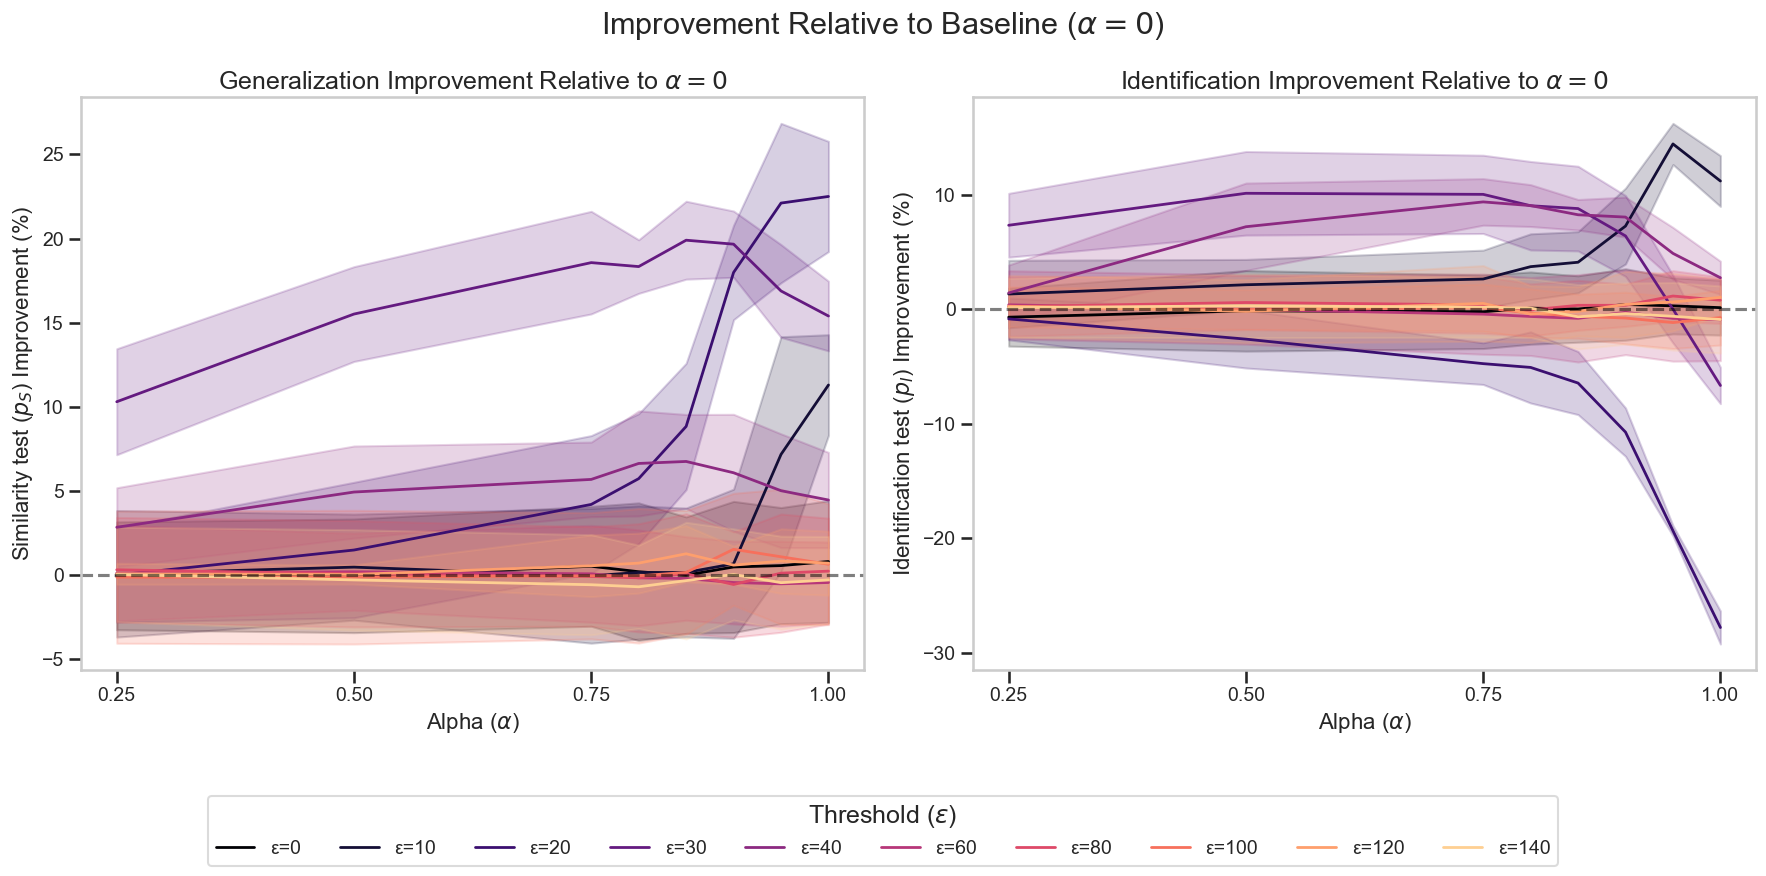

In [7]:
# Set consistent font parameters and style
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica']
})
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

# Use specific thresholds for plotting
thresholds_to_plot = [0, 10, 20, 30, 40, 60, 80, 100, 120, 140]

# Create figures for percentage improvement plots
fig1, axes1 = plt.subplots(1, 2, figsize=(18, 8))

# Create color map once - use a truncated magma colormap (matching the 0 to 0.9 range)
cmap = plt.cm.magma
colors = [cmap(i/(len(thresholds_to_plot)-1) * 0.9) for i in range(len(thresholds_to_plot))]

# For each threshold
for i, threshold in enumerate(thresholds_to_plot):
    # Get baseline scores at alpha=0.0
    baseline_g_scores = np.mean(threshold_data[0.0][threshold]['g_score'])
    baseline_i_scores = np.mean(threshold_data[0.0][threshold]['i_score'])
    
    # Prepare data for plot
    alphas = []
    g_improvements_mean = []
    g_improvements_std = []
    i_improvements_mean = []
    i_improvements_std = []
    
    # For each alpha value except 0.0 (baseline)
    for alpha in [a for a in ALPHA_VALUES if a != 0.0]:
        if alpha in threshold_data and threshold in threshold_data[alpha]:
            g_scores = threshold_data[alpha][threshold]['g_score']
            i_scores = threshold_data[alpha][threshold]['i_score']
            
            if g_scores and i_scores:
                # Calculate percentage improvements
                g_pct_improvements = [(g - baseline_g_scores) / baseline_g_scores * 100 for g in g_scores]
                i_pct_improvements = [(i - baseline_i_scores) / baseline_i_scores * 100 for i in i_scores]
                
                alphas.append(alpha)
                g_improvements_mean.append(np.mean(g_pct_improvements))
                g_improvements_std.append(np.std(g_pct_improvements))
                i_improvements_mean.append(np.mean(i_pct_improvements))
                i_improvements_std.append(np.std(i_pct_improvements))
    
    # Plot G improvements (left subplot) if we have data
    if alphas:
        # G improvements - plot line and shaded region (matching the first plot's style)
        axes1[0].plot(
            alphas, g_improvements_mean, 
            '-', color=colors[i], linewidth=2, label=f'ε={threshold}'
        )
        axes1[0].fill_between(
            alphas, 
            np.array(g_improvements_mean) - np.array(g_improvements_std),
            np.array(g_improvements_mean) + np.array(g_improvements_std),
            alpha=0.2, color=colors[i]  # Use alpha=0.2 to match first plot
        )
        
        # I improvements - plot line and shaded region
        axes1[1].plot(
            alphas, i_improvements_mean, 
            '-', color=colors[i], linewidth=2, label=f'ε={threshold}'
        )
        axes1[1].fill_between(
            alphas, 
            np.array(i_improvements_mean) - np.array(i_improvements_std),
            np.array(i_improvements_mean) + np.array(i_improvements_std),
            alpha=0.2, color=colors[i]  # Use alpha=0.2 to match first plot
        )

# Format individual improvement plots
for ax, title, ylabel in zip(axes1, 
                           ['Generalization Improvement', 'Identification Improvement'],
                           ['Similarity test ($p_S$) Improvement (%)', 'Identification test ($p_I$) Improvement (%)']):
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Alpha ($\\alpha$)', fontsize=16)  # Match font size from first plot
    ax.set_ylabel(ylabel, fontsize=16)  # Match font size from first plot
    ax.set_title(f'{title} Relative to $\\alpha=0$', fontsize=18)  # Match font size
    ax.set_facecolor('white')  # Match white background from first plot
    ax.grid(False)

# Customize tick marks for both subplots
for ax in axes1:
    # Set tick font sizes to match
    ax.tick_params(axis='both', which='major', labelsize=14)  # Match first plot font size
    
    # Set x ticks
    ax.set_xticks([0.25, 0.5, 0.75, 1.0])

# Move legend outside plots
handles, labels = axes1[0].get_legend_handles_labels()

# Place legend with same style as first plot
fig1.legend(handles, labels, title="Threshold ($\\varepsilon$)", 
           loc='upper center', bbox_to_anchor=(0.5, 0.05),  # Match position
           ncol=len(thresholds_to_plot), fontsize=14, frameon=True, 
           facecolor='white', edgecolor='lightgray')  # Match style

# Adjust layout to match first plot
plt.tight_layout(rect=[0, 0.08, 1, 0.98])  # Match the rect parameters

# Add a suptitle like the first plot (optional)
fig1.suptitle('Improvement Relative to Baseline ($\\alpha=0$)', fontsize=22, y=1.02)

plt.savefig('../results/hor_improvement_plots.pdf', bbox_inches='tight', dpi=300)
plt.show()

/tmp/ipykernel_3616793/38686220.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  magma = get_cmap('magma')


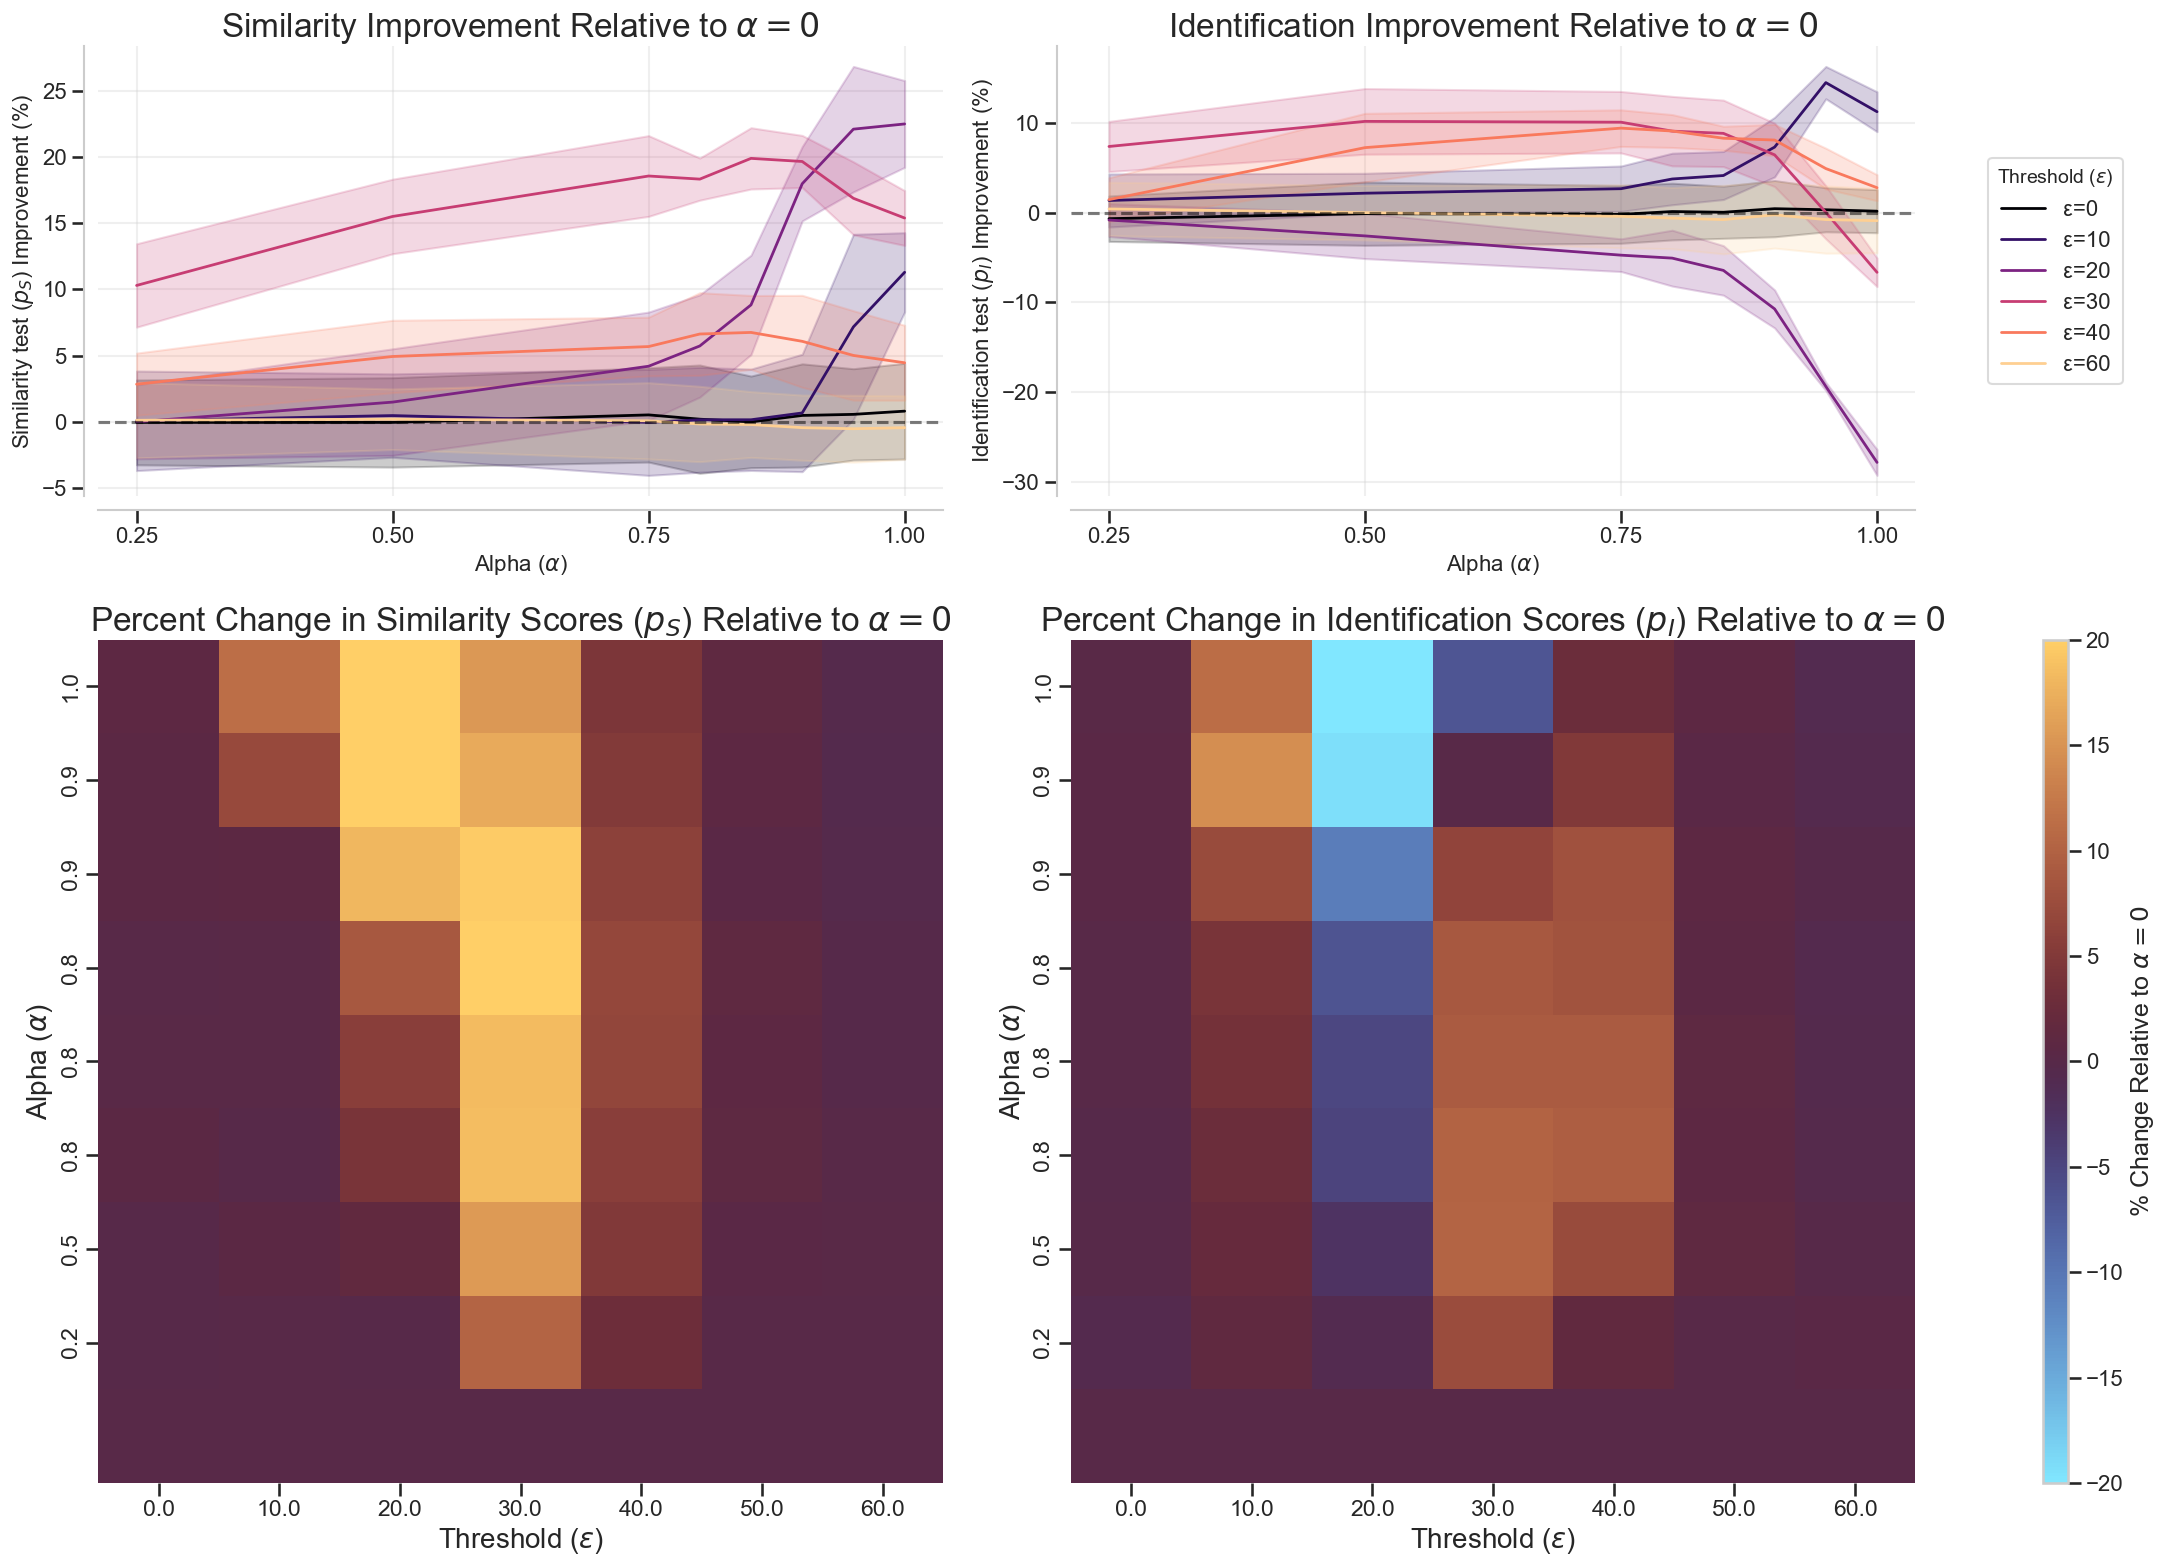

In [86]:
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Helvetica']
})
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

# Use specific thresholds for plotting
thresholds_to_plot = [0, 10, 20, 30, 40, 60]

# Create a custom diverging colormap for heatmaps
def create_diverging_magma(black_center=True):
    """
    Create a diverging colormap based on magma.
    """
    magma = get_cmap('magma')
    
    # Get purple and pink from the magma colormap ends
    purple = magma(0.35)  # Dark purple from magma
    pink = magma(0.75)   # Pink from magma
    
    if black_center:
        # Create diverging colormap with black at center
        black = (0, 0, 0, 1)
        colors = [purple, black, pink]
    else:
        # Use existing magma colors for a smooth transition
        mid_color = magma(0.5)  # Middle color from magma 
        colors = [purple, mid_color, pink]
    
    return mcolors.LinearSegmentedColormap.from_list('diverging_magma', colors, N=256)

# Create the diverging colormap for heatmaps
diverging_magma = create_diverging_magma(black_center=True)
heatmap_cmap = "managua_r"  # Using the provided colormap

# Create a figure with a GridSpec that includes space for right-side elements
fig = plt.figure(figsize=(22, 16))  # Made slightly wider for right elements

# Create a GridSpec with 2 rows and 3 columns
# First 2 columns for plots, last column for colorbar and legend
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.03], height_ratios=[0.8, 1.5])

# Create color map for line plots - use a truncated magma colormap
cmap = plt.cm.magma
colors = [cmap(i/(len(thresholds_to_plot)-1) * 0.9) for i in range(len(thresholds_to_plot))]

# Top row: Line plots 
ax1 = fig.add_subplot(gs[0, 0])  # Generalization improvement line plot
ax2 = fig.add_subplot(gs[0, 1])  # Identification improvement line plot

# Disconnect the x and y axes by adjusting the spines
for ax in [ax1, ax2]:
    # Make the spines thicker for visibility
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Offset the spines from the data
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    
    # Hide the top and right spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# For each threshold
for i, threshold in enumerate(thresholds_to_plot):
    # Get baseline scores at alpha=0.0
    baseline_g_scores = np.mean(threshold_data[0.0][threshold]['g_score'])
    baseline_i_scores = np.mean(threshold_data[0.0][threshold]['i_score'])
    
    # Prepare data for plot
    alphas = []
    g_improvements_mean = []
    g_improvements_std = []
    i_improvements_mean = []
    i_improvements_std = []
    
    # For each alpha value except 0.0 (baseline)
    for alpha in [a for a in ALPHA_VALUES if a != 0.0]:
        if alpha in threshold_data and threshold in threshold_data[alpha]:
            g_scores = threshold_data[alpha][threshold]['g_score']
            i_scores = threshold_data[alpha][threshold]['i_score']
            
            if g_scores and i_scores:
                # Calculate percentage improvements
                g_pct_improvements = [(g - baseline_g_scores) / baseline_g_scores * 100 for g in g_scores]
                i_pct_improvements = [(i - baseline_i_scores) / baseline_i_scores * 100 for i in i_scores]
                
                alphas.append(alpha)
                g_improvements_mean.append(np.mean(g_pct_improvements))
                g_improvements_std.append(np.std(g_pct_improvements))
                i_improvements_mean.append(np.mean(i_pct_improvements))
                i_improvements_std.append(np.std(i_pct_improvements))
    
    # Plot G improvements (left subplot) if we have data
    if alphas:
        # G improvements - plot line and shaded region
        ax1.plot(
            alphas, g_improvements_mean, 
            '-', color=colors[i], linewidth=2, label=f'ε={threshold}'
        )
        ax1.fill_between(
            alphas, 
            np.array(g_improvements_mean) - np.array(g_improvements_std),
            np.array(g_improvements_mean) + np.array(g_improvements_std),
            alpha=0.2, color=colors[i]
        )
        
        # I improvements - plot line and shaded region
        ax2.plot(
            alphas, i_improvements_mean, 
            '-', color=colors[i], linewidth=2, label=f'ε={threshold}'
        )
        ax2.fill_between(
            alphas, 
            np.array(i_improvements_mean) - np.array(i_improvements_std),
            np.array(i_improvements_mean) + np.array(i_improvements_std),
            alpha=0.2, color=colors[i]
        )

# Format line plots
for ax, title, ylabel in zip([ax1, ax2], 
                           ['Similarity Improvement', 'Identification Improvement'],
                           ['Similarity test ($p_S$) Improvement (%)', 'Identification test ($p_I$) Improvement (%)']):
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Alpha ($\\alpha$)', fontsize=16)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_title(f'{title} Relative to $\\alpha=0$', fontsize=24)
    ax.set_facecolor('white')
    ax.grid(True, alpha=0.3)
    ax.set_xticks([0.25, 0.5, 0.75, 1.0])
    ax.tick_params(axis='both', which='major', labelsize=16)

# Bottom row: Heatmaps
ax3 = fig.add_subplot(gs[1, 0])  # G scores heatmap
ax4 = fig.add_subplot(gs[1, 1])  # I scores heatmap

percent_min = -20
percent_max = 20

# Filter data for heatmaps to only include thresholds up to 60
max_threshold_idx = next((i for i, t in enumerate(thresholds) if t > 60), len(thresholds))
filtered_thresholds = thresholds[:max_threshold_idx]
filtered_g_percent_change = g_percent_change[:, :max_threshold_idx]
filtered_i_percent_change = i_percent_change[:, :max_threshold_idx]

# Create reversed y-tick labels (just reverse the order of alphas for labels)
reversed_y_labels = [f"{a:.1f}" for a in reversed(alphas)]

# Plot G scores percentage change heatmap (without individual colorbar)
g_heatmap = sns.heatmap(filtered_g_percent_change, annot=False, fmt=".1f", cmap=heatmap_cmap, 
            xticklabels=filtered_thresholds, yticklabels=reversed_y_labels, 
            vmin=percent_min, vmax=percent_max, center=0, ax=ax3, cbar=False)
ax3.set_xlabel('Threshold ($\\varepsilon$)', fontsize=20)
ax3.set_ylabel('Alpha ($\\alpha$)', fontsize=20)
ax3.set_title('Percent Change in Similarity Scores ($p_S$) Relative to $\\alpha=0$', fontsize=24)

# Plot I scores percentage change heatmap (without individual colorbar)
i_heatmap = sns.heatmap(filtered_i_percent_change, annot=False, fmt=".1f", cmap=heatmap_cmap, 
            xticklabels=filtered_thresholds, yticklabels=reversed_y_labels,
            vmin=percent_min, vmax=percent_max, center=0, ax=ax4, cbar=False)
ax4.set_xlabel('Threshold ($\\varepsilon$)', fontsize=20)
ax4.set_ylabel('Alpha ($\\alpha$)', fontsize=20)
ax4.set_title('Percent Change in Identification Scores ($p_I$) Relative to $\\alpha=0$', fontsize=24)

# Right side elements: Threshold legend (top) and shared colorbar (bottom)

# 1. Add vertical legend for thresholds in the top-right
legend_ax = fig.add_subplot(gs[0, 2])
legend_ax.axis('off')

# Get handles and labels from the plots
handles, labels = ax1.get_legend_handles_labels()

# Add the vertical legend
legend = legend_ax.legend(handles, labels, 
                         title="Threshold ($\\varepsilon$)",
                         loc='center',
                         fontsize=16,
                         frameon=True,
                         facecolor='white', 
                         edgecolor='lightgray')
legend.get_title().set_fontsize(14)

# 2. Add shared colorbar for heatmaps in the bottom-right
cbar_ax = fig.add_subplot(gs[1, 2])
norm = Normalize(vmin=percent_min, vmax=percent_max)
cb = ColorbarBase(cbar_ax, cmap=heatmap_cmap, norm=norm, 
                  label='% Change Relative to $\\alpha=0$',
                  orientation='vertical')
cbar_ax.yaxis.set_label_position('right')
cbar_ax.yaxis.set_ticks_position('right')
cbar_ax.tick_params(labelsize=16)

# Adjust layout
plt.tight_layout()
plt.savefig('../results/combined_lineplot_heatmap.pdf', bbox_inches='tight', dpi=300)
plt.show()